### **Practical Simple Linear Regression**

In [2]:
import pandas as pd 
import matplotlib.pyplot as plt
import numpy as np
%matplotlib inline 


In [52]:
df = pd.read_csv("height-weight.csv")
df.head()

,Weight,Height
0,74.2,178.8
1,55.8,160.0
2,77.5,183.1
3,49.8,153.9
4,64.8,169.0


Text(0, 0.5, 'Height')

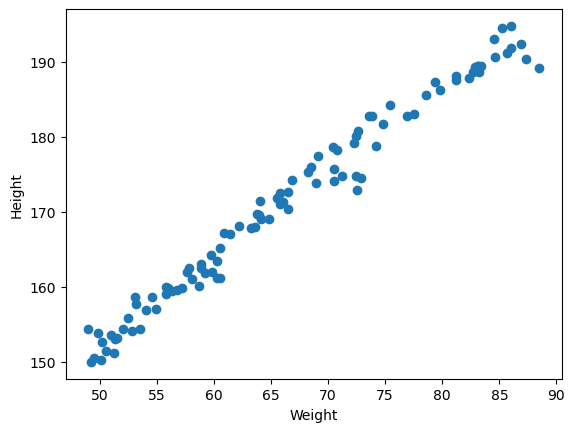

In [53]:
## scatter plot
plt.scatter(df['Weight'],df['Height'])
plt.xlabel('Weight')
plt.ylabel('Height')

In [54]:
## Correlation
df.corr()

,Weight,Height
Weight,1.000000,0.989224
Height,0.989224,1.000000


In [55]:
## Seaborn
import seaborn as sns

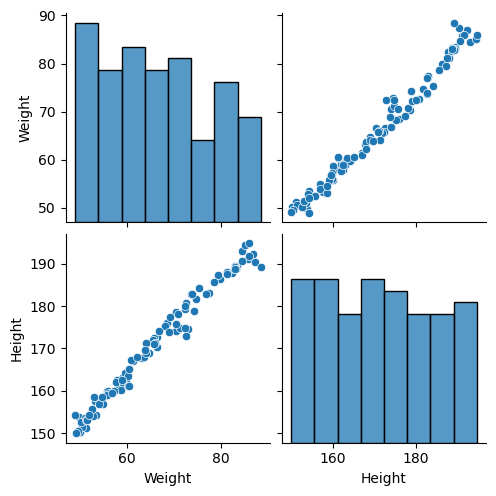

In [56]:
sns.pairplot(df)

In [57]:
## Independent and dependent feature
X = df[['Weight']]   ## independent feature should be data frame or 2-D array
y = df['Height']    ## dependent can be in 1-D array


In [58]:
X_s=df['Weight']   ## give error when fit to linear regression
np.array(X_s).shape

(100,)

In [59]:
## Train Test Split
from sklearn.model_selection import train_test_split

In [60]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=42)

In [62]:
## Standardization
from sklearn.preprocessing import StandardScaler

## **fit_transform vs transform**

> fit_transform()
- Fits the data (learns parameters like mean, std)
- Then transforms the data
- Used on **training data only**

> transform()
- Uses already learned parameters
- Only transforms the data
- Used on **test / validation data**

> Why NOT use fit_transform on test?
- Causes **data leakage**
- Model learns from test data → wrong evaluation

> Summary
- Train → `fit_transform()`
- Test → `transform()`

In [63]:
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)

In [64]:
## apply simple linear regression
from sklearn.linear_model import LinearRegression
regression=LinearRegression()

In [65]:
regression.fit(X_train,y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [66]:
print("Coefficient or Slope: ",regression.coef_)
print("Intercept : ",regression.intercept_)

Coefficient or Slope:  [12.86890966]
Intercept :  171.70933333333335


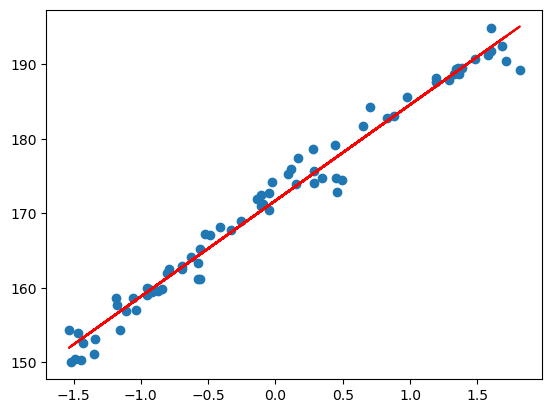

In [67]:
## plot wrt to Training Data
plt.scatter(X_train,y_train)
plt.plot(X_train,regression.predict(X_train),color='red')

## Prediction of Test data
> y_pred_test = regression.coef_ + regression.intercept_(X_test)

In [68]:
## prdeiction for test data
y_pred=regression.predict(X_test)

#### **Performance Metrics**

- from `sklearn.metrics` import `mean_absolute_error` as mae
- from `sklearn.metrics` import `mean_squared_error` as mse
- from `sklearn.metrics` import `root_mean_squared_error` as rmse

##### Metrics

- **MAE (Mean Absolute Error)**
  - Average of absolute errors
  - Robust to outliers

- **MSE (Mean Squared Error)**
  - Squares errors → penalizes large errors more

- **RMSE (Root Mean Squared Error)**
  - Square root of MSE
  - Same unit as target

In [69]:
## Performance Metrics
from sklearn.metrics import mean_absolute_error,mean_squared_error

In [70]:
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
rmse=np.sqrt(mse)
print(mse)
print(mae)
print(rmse)

4.420213118941008
1.7830840209333179
2.102430288723269


##### **R² (Coefficient of Determination)**

##### Formula
$$
R^2 = 1 - \frac{SS_{res}}{SS_{tot}}
$$

Where:
$$
SS_{res} = \sum (y_i - \hat{y}_i)^2
$$

$$
SS_{tot} = \sum (y_i - \bar{y})^2
$$

##### Meaning
- Explains variance captured by model

##### Interpretation
- $R^2 = 1$ → perfect fit  
- $R^2 = 0$ → same as mean  
- $R^2 < 0$ → worse than mean  

In [71]:
from sklearn.metrics import r2_score

In [72]:
score=r2_score(y_test,y_pred)
print(score)

0.9742703305873707


#### Adjusted R²

##### Formula
$$
R^2_{adj} = 1 - \left( \frac{(1 - R^2)(n - 1)}{n - k - 1} \right)
$$

Where:
- $R^2$ = R-squared
- $n$ = number of data points
- $k$ = number of independent variables (features)

##### Meaning
- Adjusts R² for number of features
- Penalizes adding useless variables

##### Interpretation
- Increases only if new feature improves model
- Decreases if feature adds no real value

In [73]:
## display adjusted R-squared
1-(1-score)*(len(y_test))/(len(y_test) - X_test.shape[1] - 1)

0.9720329680297507

In [74]:
## OLS Linear Regression
import statsmodels.api as sm

In [75]:
model=sm.OLS(y_train,X_train).fit()

In [77]:
prediction=model.predict(X_test)
print(prediction)

[  5.78326081  -3.48944735  -3.38035667   4.03780986 -15.5985133
  -9.81670704 -17.56214562 -17.0166922   13.85597144   7.74689312
  13.4196087   19.74686839   7.09234902 -18.10759904   7.31053039
  -2.5076312   -3.59853804  -9.16216293  18.9832336    6.00144218
  -8.61670951 -16.47123878  -7.96216541  -3.81671941 -15.92578536]


In [79]:
print(model.summary())

                                 OLS Regression Results                                
Dep. Variable:                 Height   R-squared (uncentered):                   0.006
Model:                            OLS   Adj. R-squared (uncentered):             -0.008
Method:                 Least Squares   F-statistic:                             0.4156
Date:                Mon, 08 Jun 2026   Prob (F-statistic):                       0.521
Time:                        21:23:19   Log-Likelihood:                         -492.36
No. Observations:                  75   AIC:                                      986.7
Df Residuals:                      74   BIC:                                      989.0
Df Model:                           1                                                  
Covariance Type:            nonrobust                                                  
                 coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------

In [84]:
## Prediction for new data
regression.predict(scaler.transform([[71],[73],[76]]))

d:\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


array([175.96532456, 178.14713825, 181.41985877])